# Telecom Customer Churn Analysis

**Business Question** 
- Why are customers leaving This Telecom Company? Which customers segments are most at risk of churn, and what actions can the company take to reduce
  churn

**About Dataset**
- The Telco Customer Churn dataset contains information about customers of a telecommunications company, including their demographic details, services subscribed, account information, and billing data. Each record represents an individual customer and captures their relationship with the company over time.

## 1) Importing Libraries and Loading Data 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
pd.set_option("display.max_columns", None)

In [3]:
df = pd.read_csv("datasets/Telco-Customer-Churn.csv")

## 2) Basic Data Inspecting 

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.shape

(7043, 21)

**Notes**
- The dataset have 7043 rows and 21 columns
- Each row carry data for one customer

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**Notes** 
- No missing values in the dataset
- Some column are assigned with wrong data type
- 'TotalCharges' column should be float, but is stored as object type 

In [7]:
df.describe(include="all")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


## 3) Data Cleaning and Preprocessing

#### 1) Standardizing column names

In [8]:
# Converting column names into snake_case
df.columns = df.columns.str.replace(r'(?<!^)(?=[A-Z])', '_', regex=True).str.lower()
df.columns

Index(['customer_i_d', 'gender', 'senior_citizen', 'partner', 'dependents',
       'tenure', 'phone_service', 'multiple_lines', 'internet_service',
       'online_security', 'online_backup', 'device_protection', 'tech_support',
       'streaming_t_v', 'streaming_movies', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges', 'churn'],
      dtype='object')

In [9]:
df.rename(columns={"customer_i_d": "customer_id", "streaming_t_v": "streaming_tv"}, inplace=True)

#### 2) Converting 'total_charges' into float datatype

In [10]:
df["total_charges"] = pd.to_numeric(df["total_charges"], errors="coerce")

In [11]:
df["total_charges"].isna().sum()

np.int64(11)

In [12]:
df[df["total_charges"].isna()]
# Here the missing values belong to the customers with tenure 0.(The new customers whose total_charges is not calculated yet).

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [13]:
# Filling missing values as 0
df["total_charges"] = df["total_charges"].fillna(0)

#### 3) Checking for duplicated values

In [14]:
df.duplicated().sum()

np.int64(0)

#### 4) Feature Enginnering

In [15]:
# 1) Creating a new column 'tenure_months' which groups customers into month groups

df["tenure_months"]= pd.cut(df["tenure"],  
                        bins = [0,12,24,36,48,60,72],
                        labels=['0-12','13-24','25-36','37-48','49-60','61-72'],include_lowest=True, right=True)

In [16]:
# 2) Creating an binary column from 'churn' called 'churn_binary'

df["churn_binary"] = (df["churn"] == "Yes").astype(int)

#### 5) Converting 'senior_citizen' column into more self-exploratory 

In [17]:
df["senior_citizen"] = df["senior_citizen"].map({0:"No", 1: "Yes"})

## 4) Exploratory Data Analysis

### 1) Basic Exploration

In [18]:
# Customer Churn Distribution
counts = df["churn"].value_counts()
percent = df["churn"].value_counts(normalize=True) * 100

print("Churn Customers:")
for label in counts.index:
    print(f" {label}: {counts[label]} ({percent[label]:.2f}%)")

Churn Customers:
 No: 5174 (73.46%)
 Yes: 1869 (26.54%)


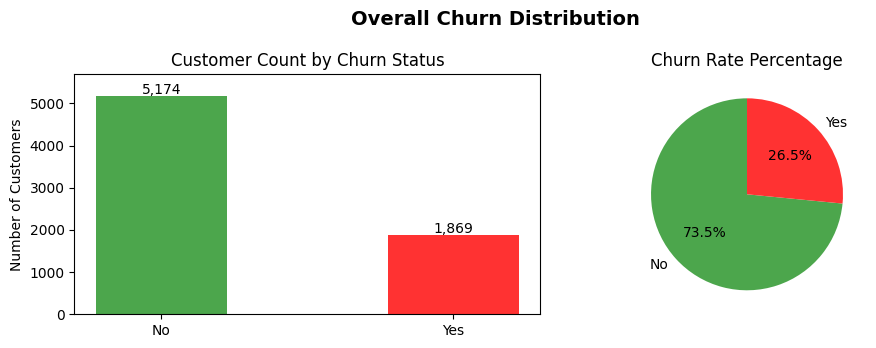

In [19]:
# Churn Distribution
fig, axes = plt.subplots(1, 2, figsize=(10,3.5))
fig.suptitle("Overall Churn Distribution", fontsize=14, fontweight="bold")

# Barplot
bars = axes[0].bar(counts.index, counts.values, color = ["#4ca64c", "#ff3232"], width= 0.45)
axes[0].set_title("Customer Count by Churn Status")
axes[0].set_ylabel("Number of Customers")
axes[0].set_ylim(0, counts.max() * 1.1)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 60,
                f"{val:,}", ha="center", fontsize=10)
                 
# Pie Chart
axes[1].pie(counts,labels = counts.index, autopct = "%1.1f%%", startangle=90,
            colors= ["#4ca64c", "#ff3232"])
axes[1].set_title("Churn Rate Percentage")

plt.tight_layout()
plt.show()

In [20]:
# Phone Service vs Internet Service
df.query("phone_service == 'No' & internet_service == 'No'").shape[0]

0

**Insight** 
- The churn rate is 26.5%, which is significantly higher than usual.
- The churn rate of 26.5% means that company is losing roughly 1 in 4 customers.
- Each customer must be subscribed to at least one of the following services: phone_service or internet_service.

### 2) Numeric distributions: Churned vs. Retained Customers

In [21]:
# Descriptive Statistics
df[["tenure", "monthly_charges", "total_charges"]].describe().round(2)

,tenure,monthly_charges,total_charges
count,7043.00,7043.00,7043.00
mean,32.37,64.76,2279.73
std,24.56,30.09,2266.79
min,0.00,18.25,0.00
25%,9.00,35.50,398.55
50%,29.00,70.35,1394.55
75%,55.00,89.85,3786.60
max,72.00,118.75,8684.80


**Insight**
- tenure: The customers tenure ranges from 0 to 72 months, median tenure -29 months.
- monthly_charges: minimum monthly ranges from `$18.25` - `$118.75`, median monthly charges - `$70`.
- total_charges: ranges from `$0` - `$8684`, median total_charges - `$1394`.

In [22]:
# Churn Analysis

print("Churn Analysis on the basis of tenure, monthly_charges and avg_total_charges.")
df.groupby("churn").agg(
    customers = ("customer_id", "count"),
    median_tenure = ("tenure", "median"),
    median_monthly_charges = ("monthly_charges", "median"),
    median_total_charges = ("total_charges", "median")).round(2).reset_index()

Churn Analysis on the basis of tenure, monthly_charges and avg_total_charges.


,churn,customers,median_tenure,median_monthly_charges,median_total_charges
0,No,5174,38.0,64.43,1679.52
1,Yes,1869,10.0,79.65,703.55


In [23]:
# Churn Rate by Tenure
print("Churn Rate by Tenure")
df.groupby("tenure_months", observed=True)["churn"].agg(customers="count",
                                churn_rate = lambda x: round((x=="Yes").mean() * 100,2)).reset_index()

Churn Rate by Tenure


,tenure_months,customers,churn_rate
0,0-12,2186,47.44
1,13-24,1024,28.71
2,25-36,832,21.63
3,37-48,762,19.03
4,49-60,832,14.42
5,61-72,1407,6.61


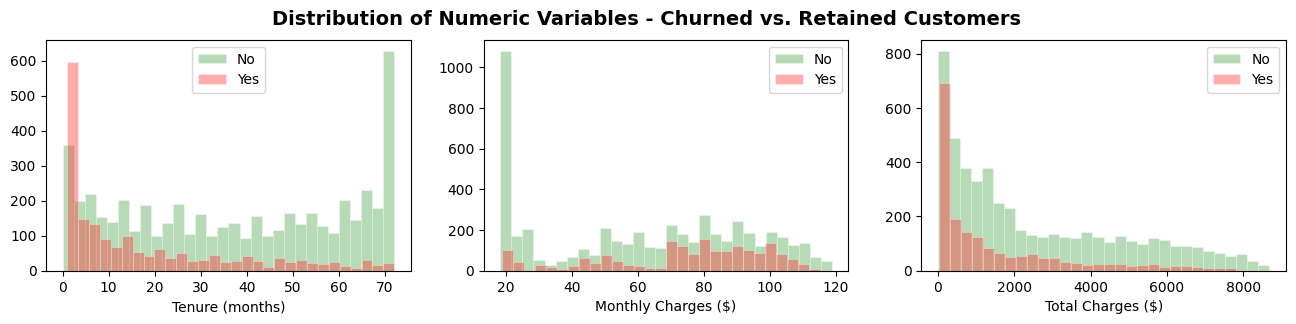

In [24]:
# Distribution of Numeric Variables - Churned vs. Retained Customers

numeric_cols = ["tenure", "monthly_charges", "total_charges"]
col_labels = ["Tenure (months)", "Monthly Charges ($)", "Total Charges ($)"]

fig, axes = plt.subplots(1, 3, figsize = (16, 3))

fig.suptitle("Distribution of Numeric Variables - Churned vs. Retained Customers", 
                         fontsize=14, fontweight="bold")

for ax, col, label in zip(axes, numeric_cols, col_labels):
    no_churn = df[df["churn"] == "No"][col]
    yes_churn = df[df["churn"] == "Yes"][col]

    ax.hist(no_churn, bins=30, alpha=0.4, label="No", color="#4ca64c", edgecolor="white", linewidth=0.5)
    ax.hist(yes_churn, bins=30, alpha=0.4,label="Yes", color= "#ff3232" ,edgecolor="white", linewidth=0.5)
    ax.set_xlabel(label)
    ax.legend()
    

plt.show()

**Insights :**
- **Tenure**: First 12 month have highest churn rate (47.44%) followed by next 12 month (28.71%)
- Old Customers are very less likely to churn.
- **Monthly Charges**: Churned customers pay approx. $15/month more then the retained customers.(churned:79.65 & retained:64.43)
- **Total Charges**: Churners have lower lifetime total, as they leave early .

### 3) Churn Rate by Customer Segment

- In this step be will try to find 'Which customer segemnts are most at risk', and for every categorical will find the churn rate 

In [25]:
# Defining Function

In [26]:
# 1) churn_calc(): This function calculate churn rate for a specific column
def churn_calc(col):

    """Return an dataframe with churn_rate and customer count for given a column 'col'
       Output: 
           group: col divided into groups
           count: total customer from that group
           churn_rate: churn percentage for that group
    """
    
    tbl = df.groupby(col)["churn_binary"].agg(churn_rate = "mean", count = "count").reset_index().sort_values("churn_rate")
    tbl["churn_rate"] = round(tbl["churn_rate"] * 100,2)
    return tbl

tbl = churn_calc("gender")
tbl

,gender,churn_rate,count
1,Male,26.16,3555
0,Female,26.92,3488


In [27]:
avg_churn_rate = df["churn_binary"].mean() * 100

In [28]:
# 2) bar_plotter(): This function plot h bar chart.


def bar_plotter(title, ax, tbl, col):

    """ Plot Horizontal bar chart of churn rate for a column. """

    colors = ["#ff3232" if val > avg_churn_rate else "#4ca64c"
                        for val in tbl["churn_rate"]]
    

    bars = ax.barh(tbl[col], tbl["churn_rate"], color= colors, height=0.55)

    ax.axvline(avg_churn_rate, color="lightgrey", linestyle="--", linewidth=1.5,
              label=f'Avg {avg_churn_rate:.1f}%')

    for bar, cr, cnt in zip(bars, tbl["churn_rate"], tbl["count"]):
        ax.text(bar.get_width() + 0.4,
        bar.get_y() + bar.get_height()/2,
        f"{cr}% \n(n={cnt:,})", va="center", fontsize=8)

    ax.set_title(title)
    ax.set_xlabel("Churn Rate(%)")
    ax.set_xlim(0, tbl["churn_rate"].max() * 1.25)
    ax.legend(fontsize=8)
    ax.grid(axis="x", alpha=0.4)
        

#### 3.1 Churn Rate by Contract Type (contract_type).

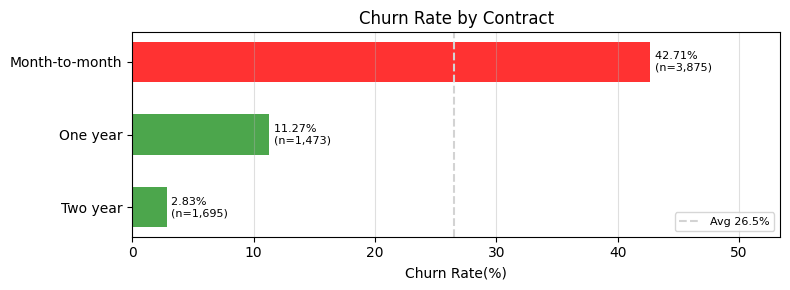

         contract  churn_rate  count
0  Month-to-month       42.71   3875
1        One year       11.27   1473
2        Two year        2.83   1695


In [29]:
tbl_contract = churn_calc("contract")

fig, ax = plt.subplots(figsize=(8,3))
bar_plotter("Churn Rate by Contract", ax, tbl_contract, "contract")
plt.tight_layout()
plt.show()

print(tbl_contract.sort_index())

**Insight**
- Month-to-Month customers have highest churn rate (**42.71%**), which is 15 times higher then two year contract customers (2.83%).
- Also over half of the customer base is on Month-to-Month plans, which is concerning.
- **Converting MoM customer into Two year or One year contract should be priority.**

#### 3.2) Churn Rate by Internet Service (internet_service)

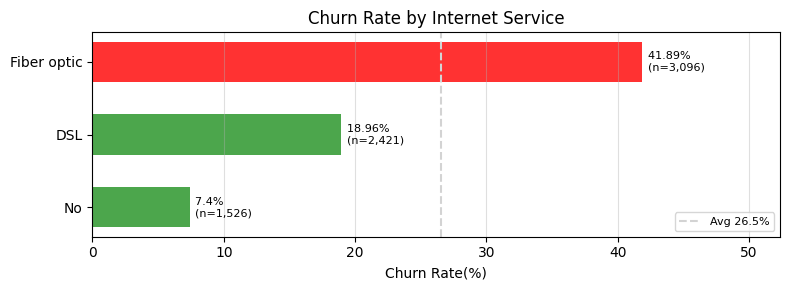

  internet_service  churn_rate  count
0              DSL       18.96   2421
1      Fiber optic       41.89   3096
2               No        7.40   1526


In [30]:
tbl_internet = churn_calc("internet_service")

fig, ax = plt.subplots(figsize= (8,3))
bar_plotter("Churn Rate by Internet Service", ax, tbl_internet, "internet_service")
plt.tight_layout()
plt.show()

print(tbl_internet.sort_index())

In [31]:
# Tenure, Monthly and Total charges by Internet Service
df.groupby("internet_service")[["monthly_charges", "total_charges", "tenure"]].mean().round(2).reset_index()

,internet_service,monthly_charges,total_charges,tenure
0,DSL,58.10,2115.41,32.82
1,Fiber optic,91.50,3205.30,32.92
2,No,21.08,662.60,30.55


**Insights**
-  Customer with Fibre optics churn at **41.89%** which is more than 2 times of DSL customer.
-  Nearly half of our customer uses Fibre optics service, and Fiber optics is also our premium service which generate highest monthly and total revenue.
-  Fibre Optics service should be neatly investigated.

#### 3.3) Customer Churn by Payment Method (payment_method).

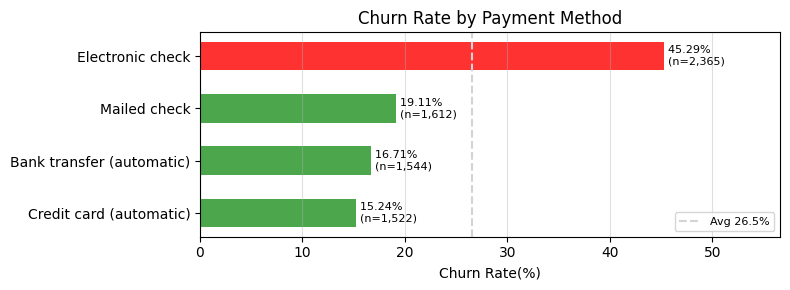

              payment_method  churn_rate  count
0  Bank transfer (automatic)       16.71   1544
1    Credit card (automatic)       15.24   1522
2           Electronic check       45.29   2365
3               Mailed check       19.11   1612


In [32]:
tbl_payment = churn_calc("payment_method")

fig, ax = plt.subplots(figsize=(8,3))
bar_plotter("Churn Rate by Payment Method", ax, tbl_payment, "payment_method")
plt.tight_layout()
plt.show()

print(tbl_payment.sort_index())

In [33]:
df.groupby("payment_method")[["monthly_charges", "total_charges", "tenure"]].mean().round(2).reset_index()

,payment_method,monthly_charges,total_charges,tenure
0,Bank transfer (automatic),67.19,3075.31,43.66
1,Credit card (automatic),66.51,3069.38,43.27
2,Electronic check,76.26,2090.87,25.17
3,Mailed check,43.92,1049.25,21.83


**Insight**
- Electronic check users churn at 45.3% - nearly 3× more than automatic payment users (~16%).
- Customer who pay manually(Electronic check, Mailed check) have higher churn rate then customer on autopay.
- Electronic check user pay higher average montlhy charges.
- Automatic pay reduce friction,(customer don't need to take action each month).

#### 3.4) Customer Churn by Tenure (tenure_months)

C:\Users\sai info bhadra\AppData\Local\Temp\ipykernel_1272\3149594902.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tbl = df.groupby(col)["churn_binary"].agg(churn_rate = "mean", count = "count").reset_index().sort_values("churn_rate")


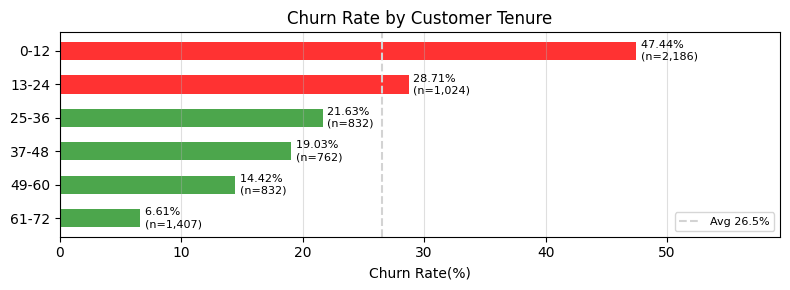

  tenure_months  churn_rate  count
0          0-12       47.44   2186
1         13-24       28.71   1024
2         25-36       21.63    832
3         37-48       19.03    762
4         49-60       14.42    832
5         61-72        6.61   1407


In [34]:
tbl_payment = churn_calc("tenure_months")

fig, ax = plt.subplots(figsize=(8,3))
bar_plotter("Churn Rate by Customer Tenure", ax, tbl_payment, "tenure_months")
plt.tight_layout()
plt.show()

print(tbl_payment.sort_index())

**Insights**
- **47.5%** of first year customers churn - means 1 in 2 customers leaves the comapny within 12 months.
- Second year also have high churn rate (28.71%).
- With each year churn rate descreases.  

#### 3.5) Churn Rate by other services (phone_service, tech_support, online_security, online_backup, streaming_tv, streaming_movies)

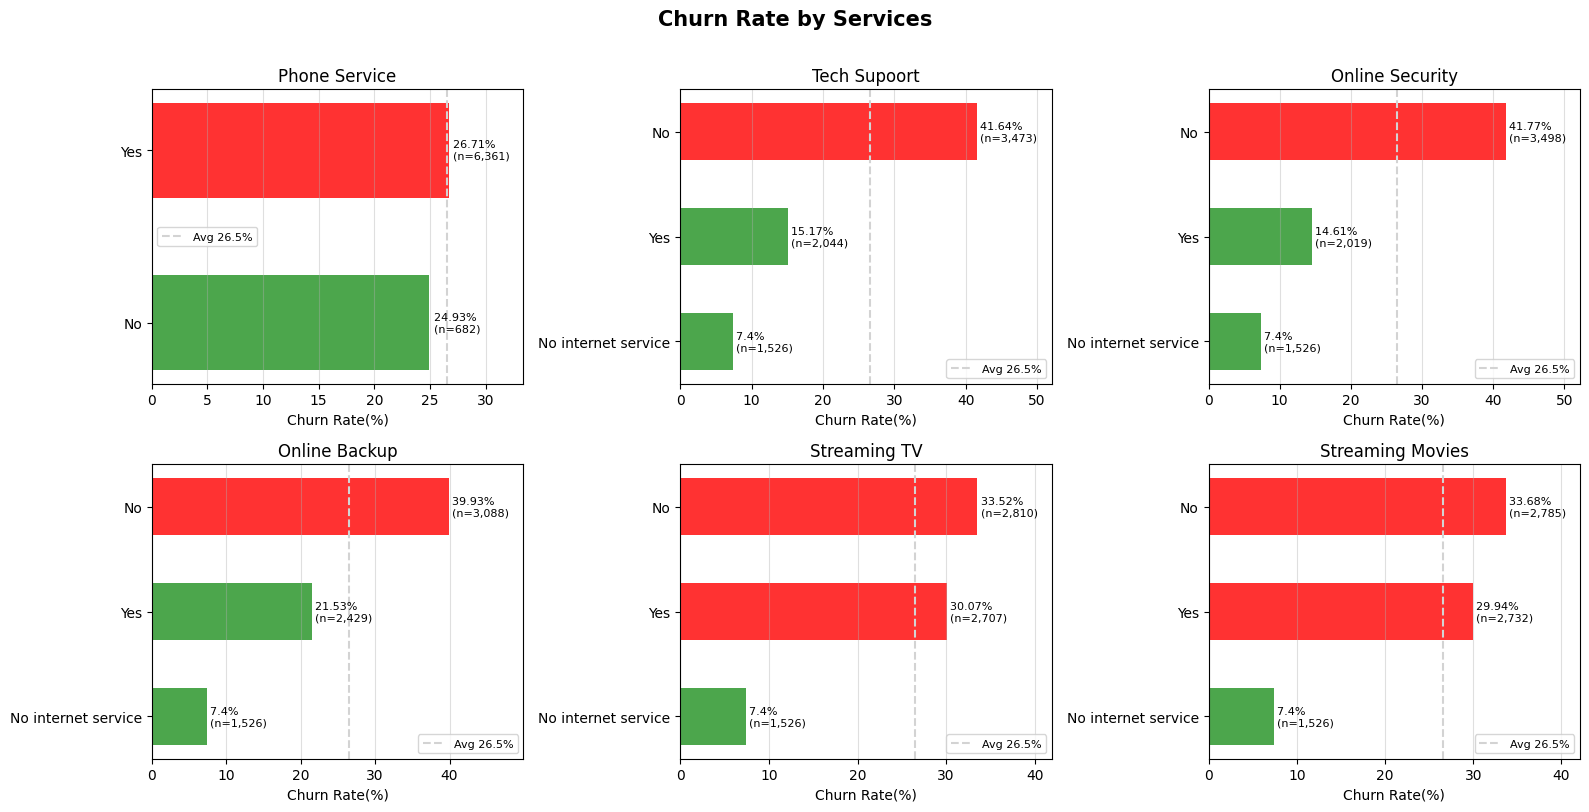

In [35]:
columns = ['phone_service','tech_support','online_security','online_backup','streaming_tv', 'streaming_movies']
titles = ['Phone Service', 'Tech Supoort','Online Security', 'Online Backup', 'Streaming TV', 'Streaming Movies']

fig, axes = plt.subplots(2,3, figsize=(16,8))
axes = axes.flatten()

for ax, col, title in zip(axes, columns, titles):
    tbl = churn_calc(col)
    bar_plotter(title, ax, tbl, col)
fig.suptitle("Churn Rate by Services", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

**Insights**
- Customers with no tech support have higher churn rate **(41.64%)**.
- Customers with no Online security have higher churn rate **(41.77%)**.
- Phone Service, Streaming TV, Streaming Movies have very less effect on churn.
- No Online Backup/ No Online Secuurity/ No Tech Support -- high risk of churn

#### 3.6 Churn Rate by Demographics

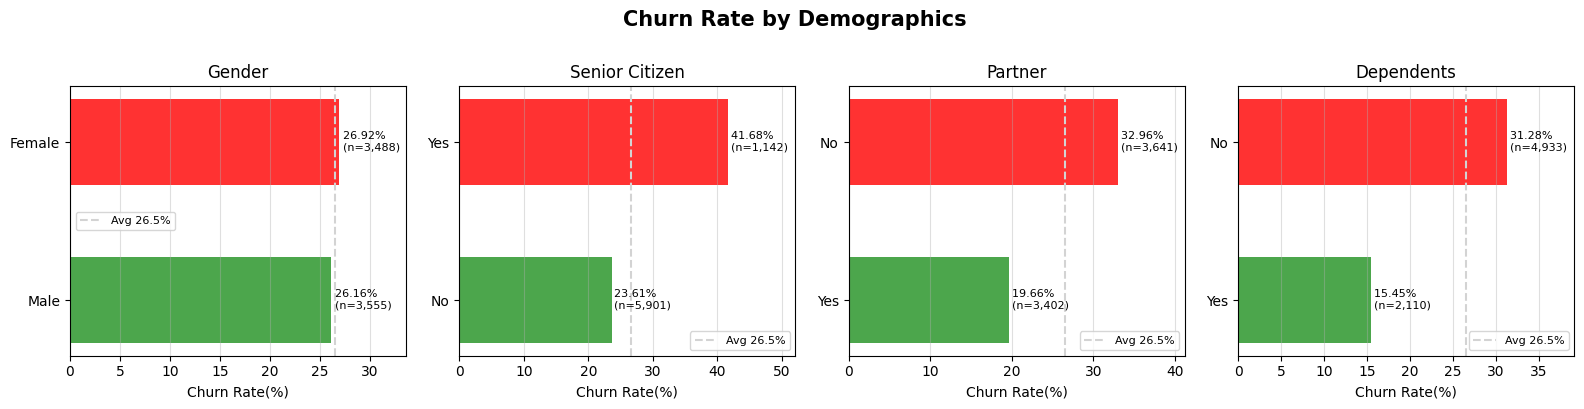

In [36]:
columns = ["gender", "senior_citizen", "partner", "dependents"]
titles = ["Gender", "Senior Citizen", "Partner", "Dependents"]

fig, axes = plt.subplots(1,4, figsize=(16, 4))

for ax, col, title in zip(axes, columns, titles):
    tbl = churn_calc(col)
    bar_plotter(title, ax, tbl, col)

fig.suptitle("Churn Rate by Demographics", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [37]:
tbl = df.groupby(["tech_support","senior_citizen"])["churn_binary"].agg(churn_rate = "mean").unstack()
tbl["churn_rate"] = round(tbl["churn_rate"] * 100,2)
tbl

churn_rate       
senior_citizen              No    Yes
tech_support                         
No                       38.82  50.60
No internet service       7.33   9.62
Yes                      14.52  19.62

**Insights**
- Gender have almost zero effect on churn.
- Senior customers churn more **(41.68%)**.
- Senior customers without tech support have 2.5x more churn rate than customer with tech support.
- Single Customer churn more **(32.96%)**.
- Customer with no dependents churn more **(31.28%)**.

#### 3.7) Stacked bar chart

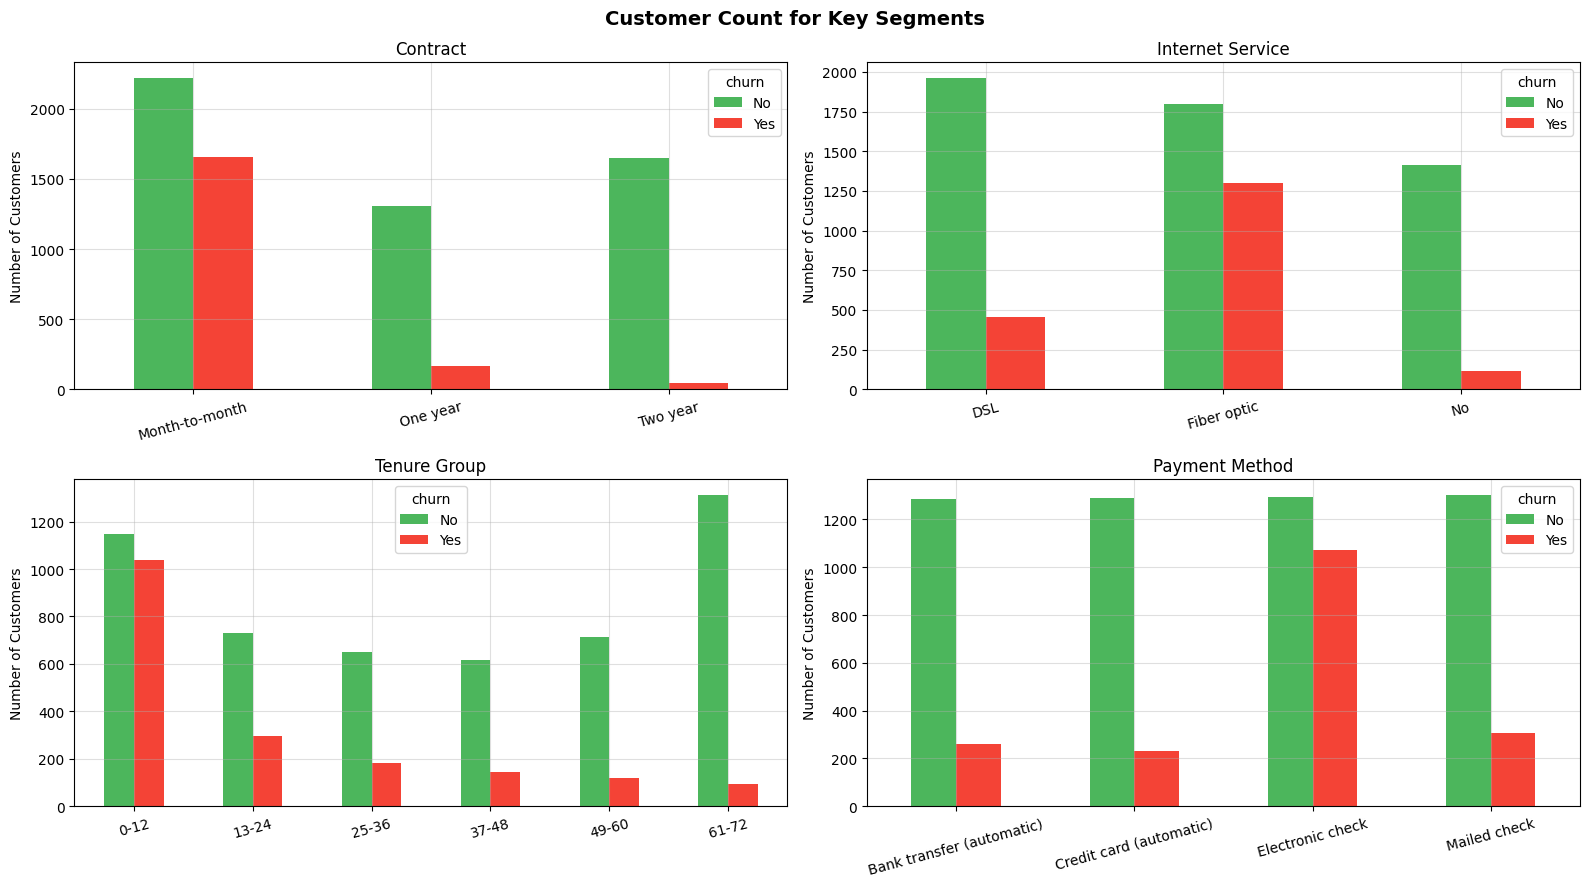

In [38]:
# Shows number of customer for each group

columns = ["contract", "internet_service", "tenure_months", "payment_method"]
titles = ["Contract", "Internet Service", "Tenure Group", "Payment Method"]

fig, axes = plt.subplots(2,2, figsize=(16,9))
axes = axes.flatten()

for ax, col, title in zip(axes, columns, titles):
    grp = df.groupby([col, "churn"], observed=False).size().unstack()
    grp.plot(kind="bar", stacked=False, ax=ax, color=["#4cb65c", "#F44336"])

    ax.set_title(title)
    ax.set_ylabel("Number of Customers")
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=15)
    ax.grid(alpha=0.4)

fig.suptitle("Customer Count for Key Segments", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

#### 3.8) Heatmap: Correlation Analysis

In [39]:
numeric_df = df[["tenure", "monthly_charges", "total_charges", "churn_binary"]]
corr = numeric_df.corr().round(3)
corr

,tenure,monthly_charges,total_charges,churn_binary
tenure,1.000,0.248,0.826,-0.352
monthly_charges,0.248,1.000,0.651,0.193
total_charges,0.826,0.651,1.000,-0.198
churn_binary,-0.352,0.193,-0.198,1.000


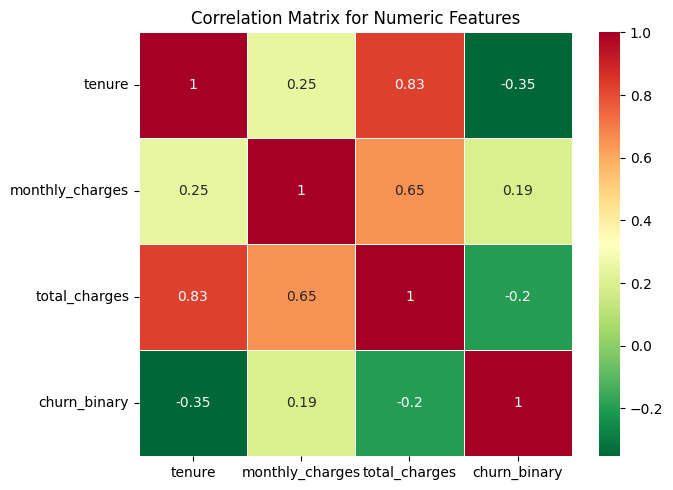

Numerical columns Correlation with Churn_binary
tenure            -0.352
total_charges     -0.198
monthly_charges    0.193
Name: churn_binary, dtype: float64


In [41]:
fig, ax = plt.subplots(figsize=(7,5))

sns.heatmap(corr, annot=True, linecolor="white", linewidths=.6, cmap="RdYlGn_r", ax=ax)
ax.set_title("Correlation Matrix for Numeric Features")

plt.tight_layout()
plt.show()

print("Numerical columns Correlation with Churn_binary")
print(corr["churn_binary"].drop("churn_binary").sort_values())

**Insights** 
- **tenure** - tenure has negative strong relation with churn **(-0.352)**, - longer the customer stays the less likely they are to leave the compnay.
- **monthly_charges** - customer who pay more monthly are more prone to leave.

# Telecom Customer Churn Analysis — Final Summary & Insights

---

## KEY NUMBERS

- **Total Customers:** 7,043  
- **Churned Customers:** 1,869 (**26.54%**)  
- **Retained Customers:** 5,174 (**73.46%**)  

>  **Churn rate of 26.54% is critically high** — the company is losing **~1 in every 4 customers**

---

## High-Risk Segments at a Glance

1. Month-to-month contracts -> **42.7% churn** (3,875 customers)
2. Fiber optic subscribers -> **41.9% churn** (3,096 customers)
3. Electronic check payers -> **45.3% churn** (2,365 customers)
4. New customers first 12 month -> **47.7% churn** (2,175 customers)
5. Senior citizens -> **41.7% churn** (1,142 customers)
6. No Tech Support -> **41.6% churn** (3,473 customers)

## Main Churn Drivers
1. **Tenure** -> short tenure means very high risk
2. **Contract Type** -> month-to-month is danger zone
3. **Online Security** & **Tech Supoort** -> without these services churn doubles
4. **Payment Method** -> manual payment means more likely to churn

---

## Insights 
1. **Key Insights**
   
    - Overall churn rate is **26.54%**, meaning the company is losing **~1 in 4 customers**, which is significantly high.  
    - Churned customers pay **~$15 more per month** (79.65 vs 64.43), indicating higher price sensitivity.  
    - First-year customers have the highest churn (**~47.5%**), which drops to **28.7%** in the second year.

    <br>  
2. **Contract Type**
    - Month-to-Month customers have the highest churn (**42.71%**), which is **~15× higher than two-year contracts (2.83%)** and **~4× higher than   one-year contracts (11.27%)**.  
    - Over **50% of the customer base** is on Month-to-Month plans, increasing overall churn risk.
      
    <br>
3. **Internet Service**
    - Fiber optic customers churn at **41.89%**, which is more than **2× DSL customers**.  
    - Fiber is a **premium, high-revenue service**, and nearly half of customers use it—making this a critical risk area.
    <br>
4. **Payment Method**
    - Electronic check users have the highest churn (**45.3%**), nearly **3× higher than auto-pay users (~16%)**.  
    - Customers using **manual payment methods** (electronic or mailed checks) churn more than those on automatic payments.
    <br>
5. **Customer Tenure**
    - **47.5% of customers churn within the first year**, meaning 1 in 2 customers leaves early.  
    - The second year still shows relatively high churn (**28.7%**).  
    - Churn rate **consistently decreases with increasing tenure**, indicating stronger retention over time.
    <br>
6. **Other Services**
    - Customers without **tech support** have a higher churn rate (**41.64%**).  
    - Customers without **online security** have a higher churn rate (**41.77%**).  
    - No Tech supoort/ No Online Security -> **high churn risk segment**.
    <br>
7. **Demographics**
    - **Senior citizens** have higher churn (**41.68%**).  
    - Senior customers without tech support have **~2.5× higher churn** than those with support.  
    - **Single customers (32.96%)** and customer with **no dependents (31.28%)** churn more.  
    - Gender have almost zero effect on churn.

--- 
## RECOMMENDED ACTIONS

1) **CONTRACT CONVERSION**
   Try to convert month-to-month customers to switch to annual plans.
   We can offer discounts, or small benefits to push them toward 1-year or 2-year contracts.
   

2) **FIBER OPTICS  SERVICE**
    Fiber customers generate high revenue but also have very high churn (41.9%), so it is a risky segment.
    We should check service quality (speed, downtime, reliability) and collect customer feedback to find issues
    We can also give extra benefits like OTT subscriptions (movies/TV) to fiber optics customers.


3) **Payment Method**
   Customers using manual payment(like electronic check) have very high churn.
   We should encourage them to switch to auto-pay by giving small discounts or cashback.
   Auto-pay makes payment easier and reduces chances of churn.

4) **Tech Support and Online Security**
    Customers without tech support or online security have high churn (~41%).
    We can bundle these services with plans or give a free 3–6 month trial.

5) **Early Customer Retention**
    Around 47% customers churn in the first year, which is very high.
    We should focus on new customers by giving early support, and regular follow-ups.
   
6) **Senior Citizen Programme**
    Senior customers have higher churn (~41%).
    We can provide dedicated support, simple billing, and technical help for them.